In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from stock_screener import fetch_screener_data

sns.set_theme(style="darkgrid")
stock_pool = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "TSLA"]
raw_data = fetch_screener_data(stock_pool)

raw_data["Close"].head()

Matplotlib is building the font cache; this may take a moment.
/Users/jasonshi/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Fetching historical data for companies: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'TSLA']...


[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA,TSLA
Date,,,,,,
2026-04-14,258.591736,249.020004,332.910004,392.260406,196.509995,364.200012
2026-04-15,266.184753,248.500000,337.119995,410.331268,198.869995,391.950012
2026-04-16,263.157532,249.699997,336.019989,419.351746,198.350006,388.899994
2026-04-17,269.981262,250.559998,341.679993,421.876282,201.679993,400.619995
2026-04-20,272.798645,248.279999,337.420013,417.166473,202.059998,392.500000


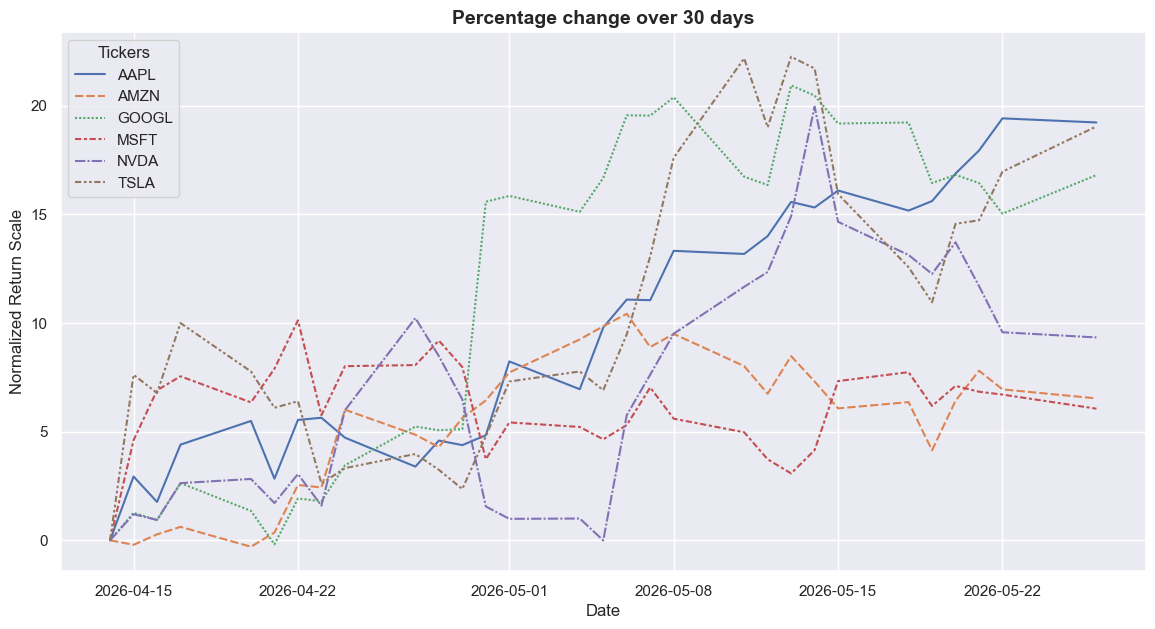

In [6]:
close_prices = raw_data["Close"]
pct_close = (close_prices - close_prices.iloc[0]) / close_prices.iloc[0] * 100

plt.figure(figsize=(14,7))
sns.lineplot(data=pct_close)

plt.title("Percentage change over 30 days", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Percent (0 as starting price)", fontsize=12)
plt.legend(title="Stocks")
plt.show()

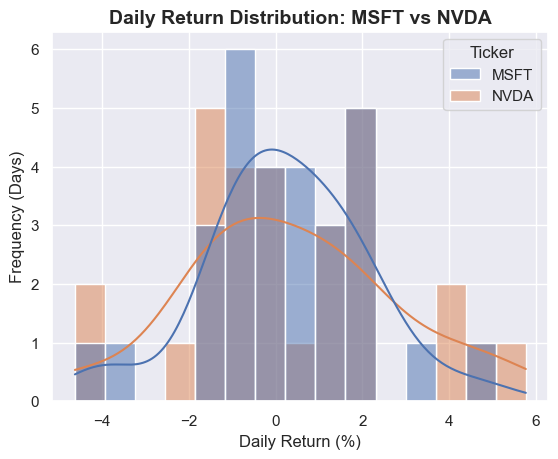

In [7]:
daily_returns = close_prices.pct_change() * 100
sns.histplot(data=daily_returns[["MSFT", "NVDA"]], kde=True, bins=15, alpha=0.5)

plt.title("Daily Return Distribution: MSFT vs NVDA", fontsize=14, fontweight='bold')
plt.xlabel("Daily Return (%)", fontsize=12)
plt.ylabel("Frequency (Days)", fontsize=12)

plt.show()